In [50]:
"""Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services."""
# =========================================================
# DB NAVIGATOR APP REVIEW ANALYSIS
#
# Research Goal:
# Analyze public app store reviews of DB Navigator to identify
# user satisfaction, recurring complaints, feature requests,
# and factors influencing user engagement.
#
# Apply text mining and sentiment analysis to extract
# actionable insights that can guide the design and
# improvement of user-centered digital public services.
#
# Research Questions:
# - What aspects of DB Navigator do users value most?
# - What are the most common sources of user frustration?
# - Which topics have the greatest impact on user satisfaction?
#
# Dataset:
# Public Google Play Store reviews of DB Navigator
# (App ID: de.hafas.android.db)
#
# =========================================================

'Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services.'

In [51]:
# =========================================================
# 1. INSTALL REQUIRED LIBRARIES
#
# Run this only once.
# These libraries are used for:
#
# - data analysis
# - visualization
# - text mining
# - sentiment analysis
# - topic modeling
#
# =========================================================
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud textblob

# =========================================================
# 2. IMPORT LIBRARIES
#
# pandas      -> data handling
# numpy       -> numerical operations
# matplotlib  -> plotting
# seaborn     -> better visualizations
# Counter     -> count word frequencies
# WordCloud   -> generate word clouds
# sklearn     -> topic modeling
# TextBlob    -> sentiment analysis
# nltk        -> stopwords
# re          -> text cleaning with regex
#
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords

import re


import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.backends.mps.is_available())

# =========================================================
# 3. DOWNLOAD NLTK STOPWORDS
#
# Stopwords are common words like:
# "und", "oder", "der", "die"
#
# These words do not carry much meaning
# for text mining.
#
# =========================================================

nltk.download('stopwords')

2.12.1+cu130
False
False


[nltk_data] Downloading package stopwords to /home/amir/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
# =========================================================
# LOAD SENTIMENT ANALYSIS MODEL
#
# We use a multilingual transformer model
# for sentiment analysis of German reviews.
#
# =========================================================

from transformers import pipeline

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="tabularisai/multilingual-sentiment-analysis",
    device=-1,          # CPU
    truncation=True
)

print("Sentiment model loaded successfully.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13701.71it/s]


Sentiment model loaded successfully.


In [53]:
# =========================================================
# 4. LOAD DATASET
#
# Read the CSV file containing app reviews.
#
# =========================================================

reviews = pd.read_csv("data/db_navigator_reviews.csv")

In [54]:
# =========================================================
# 5. VIEW FIRST ROWS
#
# Quick inspection of the dataset.
#
# head() shows the first 5 rows.
#
# =========================================================

reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,14fec7bb-b9d0-42ec-a449-ae767dafc58e,Oliver Bschor,https://play-lh.googleusercontent.com/a/ACg8oc...,völlig unübersichtliche Bedienoberfläche,1,0,26.11.0,2026-06-27 15:08:36,NaN,NaN,26.11.0
1,f7f95b83-a988-4d69-82b3-e4a63bd34aef,Heike Veit,https://play-lh.googleusercontent.com/a-/ALV-U...,Gute Bedienbarkeit.,5,0,26.11.0,2026-06-27 12:41:37,NaN,NaN,26.11.0
2,8f966e81-dca5-4076-87b7-42e1a9cf69e1,Thomas Lichtenfeld,https://play-lh.googleusercontent.com/a/ACg8oc...,Soweit ok.,4,0,NaN,2026-06-27 12:01:03,NaN,NaN,NaN
3,a5275f68-dc30-46c6-916e-711fe01fe51c,Gerd Urban,https://play-lh.googleusercontent.com/a-/ALV-U...,"Einloggen nicht möglich, Seite öffnet sich nic...",1,0,26.11.0,2026-06-27 11:49:13,NaN,NaN,26.11.0
4,8346cb9e-7ab6-4d92-8664-0b102d04eb98,R Manz,https://play-lh.googleusercontent.com/a/ACg8oc...,An sich hat bisher immer alles gut funktionier...,3,0,26.11.0,2026-06-27 10:41:27,NaN,NaN,26.11.0


In [55]:
# =========================================================
# 6. BASIC DATASET INFORMATION
#
# - shape      -> number of rows and columns
# - columns    -> dataset column names
# - isnull()   -> missing values
#
# =========================================================

print("Dataset Shape:")
print(reviews.shape)

print("\nColumns:")
print(reviews.columns)

print("\nMissing Values:")
print(reviews.isnull().sum())
reviews['score'].value_counts().sort_index()

Dataset Shape:
(73518, 11)

Columns:
Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')

Missing Values:
reviewId                    0
userName                    0
userImage                   0
content                    76
score                       0
thumbsUpCount               0
reviewCreatedVersion     6205
at                          0
replyContent            57875
repliedAt               57875
appVersion               6205
dtype: int64


score
0       18
1    29605
2     7681
3     6260
4     8488
5    21466
Name: count, dtype: int64

In [56]:
# =========================================================
# 7. CLEAN DATASET
#
# Steps:
#
# 1. Remove rows with missing reviews
# 2. Remove invalid ratings (0 stars)
# 3. Convert review text to string
# 4. Remove duplicate reviews
#
# =========================================================

# Remove reviews without text
reviews = reviews.dropna(subset=["content"]).copy()

# Remove invalid ratings (0 stars)
reviews = reviews[reviews["score"].between(1, 5)].copy()

# Ensure review text is stored as strings
reviews["content"] = reviews["content"].astype(str)

# Remove duplicate reviews
reviews = reviews.drop_duplicates(subset=["content"])


# =========================================================
# 8. LOAD GERMAN STOPWORDS
#
# Stopwords are removed because they appear
# very frequently but provide little semantic value.
#
# Additional domain-specific stopwords are added
# manually for DB Navigator reviews.
#
# NOTE:
# The original review text ("content") will be used
# for sentiment analysis.
# The cleaned text is only used for topic modeling,
# keyword analysis, and word frequency analysis.
#
# =========================================================

stop_words = set(stopwords.words("german"))

custom_stopwords = {

    # -----------------------------------------------------
    # APP / DOMAIN
    # -----------------------------------------------------
    "app",
    "apps",
    "db",
    "navigator",
    "bahn",

    # -----------------------------------------------------
    # GENERIC POSITIVE / NEGATIVE
    # -----------------------------------------------------
    "gut",
    "gute",
    "besser",
    "beste",
    "super",
    "toll",
    "perfekt",
    "klasse",
    "prima",

    # -----------------------------------------------------
    # VERY COMMON FILLER WORDS
    # -----------------------------------------------------
    "mehr",
    "immer",
    "mal",
    "seit",
    "schon",
    "noch",
    "ganz",
    "gar",
    "wirklich",
    "eigentlich",
    "einfach",
    "leider",
    "bitte",
    "danke",

    # -----------------------------------------------------
    # COMMON VERBS
    # -----------------------------------------------------
    "funktioniert",
    "funktionieren",
    "funktioniere",
    "geht",
    "gehen",
    "macht",
    "machen",
    "läuft",
    "laufen",
    "lief",
    "finde",
    "finden",
    "gibt",
    "geben",
    "wurde",
    "worden",
    "kommt",
    "kommen",
    "war",
    "waren",
    "ist",
    "sind",
    "bin",

    # -----------------------------------------------------
    # TIME WORDS
    # -----------------------------------------------------
    "heute",
    "morgen",
    "gestern",
    "jetzt",
    "bereits",
    "oft",

    # -----------------------------------------------------
    # MISC
    # -----------------------------------------------------
    "also",
    "halt",
    "bzw",
    "usw",
}
stop_words.update(custom_stopwords)


# =========================================================
# 9. TEXT PREPROCESSING FUNCTION
#
# This function cleans review text.
#
# Steps:
#
# 1. Convert text to lowercase
# 2. Remove URLs
# 3. Remove numbers
# 4. Remove punctuation and special characters
# 5. Tokenize text
# 6. Remove stopwords
#
# =========================================================

def preprocess_text(text):

    # convert text to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation/special characters
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", "", text)

    # tokenize
    tokens = text.split()

    # remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # join tokens back into text
    return " ".join(tokens).strip()


# =========================================================
# 10. APPLY TEXT CLEANING
#
# Create a new column:
#
# clean_text
#
# containing the cleaned review text.
#
# =========================================================

reviews["clean_text"] = reviews["content"].apply(preprocess_text)


# =========================================================
# 11. COMPARE ORIGINAL VS CLEANED TEXT
#
# Useful for verifying preprocessing quality.
#
# =========================================================

reviews[["content", "clean_text"]].head()

print(f"Remaining reviews: {len(reviews):,}")
print(reviews["score"].value_counts().sort_index())

Remaining reviews: 67,427
score
1    29244
2     7631
3     6130
4     7542
5    16880
Name: count, dtype: int64


In [57]:
# =========================================================
# BERTopic Topic Modeling (TEST)
#
# Automatically discover discussion topics
# in a sample of DB Navigator reviews.
#
# =========================================================

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# Create a sample for testing
# ---------------------------------------------------------

sample_reviews = reviews.sample(
    5000,
    random_state=42
)

print(f"Testing on {len(sample_reviews)} reviews")

# ---------------------------------------------------------
# Load embedding model
# ---------------------------------------------------------

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

# ---------------------------------------------------------
# Create BERTopic model
# ---------------------------------------------------------

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    min_topic_size=10,
    nr_topics="auto",
    calculate_probabilities=False,
    verbose=True,
)

# ---------------------------------------------------------
# Train model
# ---------------------------------------------------------

topics, _ = topic_model.fit_transform(
    sample_reviews["clean_text"].tolist()
)

# ---------------------------------------------------------
# Store results
# ---------------------------------------------------------

sample_reviews["topic"] = topics

# ---------------------------------------------------------
# Show discovered topics
# ---------------------------------------------------------

topic_info = topic_model.get_topic_info()

print(topic_info)

# ---------------------------------------------------------
# Show top words for each topic
# ---------------------------------------------------------

print("\n================ DISCOVERED TOPICS ================\n")

for topic_id in topic_info["Topic"]:

    if topic_id == -1:
        continue

    print(f"\nTopic {topic_id}")

    words = topic_model.get_topic(topic_id)

    print(", ".join(word for word, _ in words[:10]))

# ---------------------------------------------------------
# Topic frequencies
# ---------------------------------------------------------

print("\nTopic frequencies:\n")

print(sample_reviews["topic"].value_counts().sort_index())

# ---------------------------------------------------------
# Compare topics with ratings
# ---------------------------------------------------------

topic_rating = pd.crosstab(
    sample_reviews["topic"],
    sample_reviews["score"]
)

print("\nTopic vs Rating:\n")

print(topic_rating)

Testing on 5000 reviews


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14220.89it/s]
2026-06-28 17:36:34,729 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 157/157 [00:37<00:00,  4.14it/s]
2026-06-28 17:37:12,672 - BERTopic - Embedding - Completed ✓
2026-06-28 17:37:12,673 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-28 17:37:14,590 - BERTopic - Dimensionality - Completed ✓
2026-06-28 17:37:14,591 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-28 17:37:14,713 - BERTopic - Cluster - Completed ✓
2026-06-28 17:37:14,714 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-28 17:37:14,783 - BERTopic - Representation - Completed ✓
2026-06-28 17:37:14,785 - BERTopic - Topic reduction - Reducing number of topics
2026-06-28 17:37:14,796 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-28 17:37:14,856 - BERTopic - Representation -

    Topic  Count                                               Name  \
0      -1   1485             -1_angezeigt_update_verbindung_möglich   
1       0   1258                     0_ticket_tickets_zug_angezeigt   
2       1    223                           1_meckern_müll_geil_mist   
3       2    204               2_verspätungen_datum_verspätung_spät   
4       3    184                3_android_galaxy_samsung_smartphone   
5       4    174           4_update_bahncard_letzten_aktualisierung   
6       5    140          5_verbindungen_verbindung_zeigt_angezeigt   
7       6     97                    6_richtig_einwandfrei_echt_must   
8       7     88                    7_login_passwort_anmelden_email   
9       8     84          8_sparpreisfinder_paypal_zahlung_bezahlen   
10      9     67                 9_leicht_schnelle_schnell_einfache   
11     10     60          10_komfort_checkin_komfortcheckin_comfort   
12     11     49         11_deutsche_berlin_deutschen_unzuverlässig   
13    

In [58]:
topic_info = topic_model.get_topic_info()

print(topic_info)

    Topic  Count                                               Name  \
0      -1   1485             -1_angezeigt_update_verbindung_möglich   
1       0   1258                     0_ticket_tickets_zug_angezeigt   
2       1    223                           1_meckern_müll_geil_mist   
3       2    204               2_verspätungen_datum_verspätung_spät   
4       3    184                3_android_galaxy_samsung_smartphone   
5       4    174           4_update_bahncard_letzten_aktualisierung   
6       5    140          5_verbindungen_verbindung_zeigt_angezeigt   
7       6     97                    6_richtig_einwandfrei_echt_must   
8       7     88                    7_login_passwort_anmelden_email   
9       8     84          8_sparpreisfinder_paypal_zahlung_bezahlen   
10      9     67                 9_leicht_schnelle_schnell_einfache   
11     10     60          10_komfort_checkin_komfortcheckin_comfort   
12     11     49         11_deutsche_berlin_deutschen_unzuverlässig   
13    

In [59]:
# =========================================================
# 12. DEFINE FEATURE KEYWORDS
#
# Manually define important feature categories
# for DB Navigator.
#
# These keywords help identify:
#
# - usability issues
# - technical problems
# - ticketing experience
# - journey planning
# - user expectations
#
# The categories are later used to measure
# how frequently users discuss each topic.
#
# =========================================================

feature_keywords = {
    # -----------------------------------------------------
    # USER EXPERIENCE / USABILITY
    # -----------------------------------------------------
    "Usability": [
        "übersichtlich",
        "bedienung",
        "benutzerfreundlich",
        "einfach",
        "simpel",
        "verständlich",
        "klar",
        "intuitiv",
        "navigation",
        "oberfläche",
        "menü",
        "menüführung",
        "sidebar",
    ],
    # -----------------------------------------------------
    # TECHNICAL PROBLEMS / BUGS
    # -----------------------------------------------------
    "Bug Reports": [
        "bug",
        "bugs",
        "fehler",
        "problem",
        "probleme",
        "absturz",
        "abgestürzt",
        "stürzt",
        "crash",
        "hängt",
        "hängen",
        "störung",
        "defekt",
        "kaputt",
    ],
    # -----------------------------------------------------
    # PERFORMANCE / STABILITY
    # -----------------------------------------------------
    "Performance": [
        "schnell",
        "langsam",
        "stabil",
        "instabil",
        "performance",
        "ladezeit",
        "reaktion",
        "flüssig",
        "hängt",
        "läuft",
    ],
    # -----------------------------------------------------
    # JOURNEY PLANNING
    # -----------------------------------------------------
    "Journey Planning": [
        "verbindung",
        "verbindungen",
        "fahrplan",
        "reise",
        "umsteigen",
        "bahnhof",
        "gleis",
        "ankunft",
        "abfahrt",
        "ziel",
        "strecke",
        "zug",
        "ice",
        "ic",
        "nahverkehr",
        "google",
        "maps",
    ],
    # -----------------------------------------------------
    # TICKETS & BOOKING
    # -----------------------------------------------------
    "Tickets": [
        "ticket",
        "tickets",
        "deutschlandticket",
        "bahncard",
        "buchen",
        "buchung",
        "reservierung",
        "reservieren",
        "qr",
        "barcode",
        "ecoupon",
    ],
    # -----------------------------------------------------
    # PAYMENT
    # -----------------------------------------------------
    "Payment": [
        "paypal",
        "zahlung",
        "zahlungen",
        "zahlen",
        "bezahlen",
        "zahlungsmittel",
        "preis",
        "preise",
    ],
    # -----------------------------------------------------
    # LOGIN & ACCOUNT
    # -----------------------------------------------------
    "Account": [
        "login",
        "einloggen",
        "anmelden",
        "abmelden",
        "konto",
        "passwort",
        "benutzername",
        "nutzername",
        "email",
        "mailadresse",
        "registrieren",
        "profil",
    ],
    # -----------------------------------------------------
    # DELAYS & NOTIFICATIONS
    # -----------------------------------------------------
    "Delays & Notifications": [
        "verspätung",
        "verspätet",
        "ausfall",
        "benachrichtigung",
        "push",
        "meldung",
        "informationen",
        "warnung",
    ],
    # -----------------------------------------------------
    # WIDGETS
    # -----------------------------------------------------
    "Widgets": ["widget", "widgets"],
    # -----------------------------------------------------
    # DESIGN
    # -----------------------------------------------------
    "Design": [
        "design",
        "layout",
        "optik",
        "modern",
        "oberfläche",
        "ansicht",
        "darstellung",
        "redesign",
    ],
    # -----------------------------------------------------
    # DEVICE COMPATIBILITY
    # -----------------------------------------------------
    "Compatibility": [
        "android",
        "samsung",
        "galaxy",
        "tablet",
        "tablett",
        "querformat",
        "hochformat",
        "browser",
        "chrome",
        "firefox",
    ],
    # -----------------------------------------------------
    # FEATURE REQUESTS
    # -----------------------------------------------------
    "Feature Requests": [
        "wunsch",
        "feature",
        "funktion",
        "verbessern",
        "fehlt",
        "hinzufügen",
        "erweitern",
        "möglichkeit",
    ],
}


================ FEATURE ANALYSIS ================


===== 1 Star Reviews =====



,Feature,Rating,Mentions,Percentage
20,Tickets,1,7657,26.183149
15,Journey Planning,1,7026,24.025441
5,Bug Reports,1,3770,12.891533
30,Account,1,3181,10.877445
35,Delays & Notifications,1,2100,7.180960
25,Payment,1,1516,5.183969
50,Compatibility,1,1349,4.612912
55,Feature Requests,1,1265,4.325674
10,Performance,1,910,3.111749
0,Usability,1,720,2.462043



===== 2 Star Reviews =====



,Feature,Rating,Mentions,Percentage
16,Journey Planning,2,2293,30.048486
21,Tickets,2,2210,28.960818
6,Bug Reports,2,1049,13.746560
31,Account,2,649,8.504783
36,Delays & Notifications,2,577,7.561263
56,Feature Requests,2,507,6.643952
26,Payment,2,452,5.923208
51,Compatibility,2,346,4.534137
11,Performance,2,301,3.944437
1,Usability,2,246,3.223693



===== 3 Star Reviews =====



,Feature,Rating,Mentions,Percentage
17,Journey Planning,3,1825,29.771615
22,Tickets,3,1477,24.094617
7,Bug Reports,3,720,11.745514
57,Feature Requests,3,494,8.058728
37,Delays & Notifications,3,417,6.802610
32,Account,3,370,6.035889
27,Payment,3,311,5.073409
52,Compatibility,3,274,4.469821
2,Usability,3,244,3.980424
12,Performance,3,240,3.915171



===== 4 Star Reviews =====



,Feature,Rating,Mentions,Percentage
18,Journey Planning,4,1453,19.265447
23,Tickets,4,1024,13.577300
8,Bug Reports,4,615,8.154336
58,Feature Requests,4,460,6.099178
13,Performance,4,436,5.780960
3,Usability,4,432,5.727924
38,Delays & Notifications,4,404,5.356669
28,Payment,4,234,3.102625
53,Compatibility,4,207,2.744630
33,Account,4,176,2.333599



===== 5 Star Reviews =====



,Feature,Rating,Mentions,Percentage
19,Journey Planning,5,1955,11.581754
4,Usability,5,1262,7.476303
24,Tickets,5,1205,7.138626
14,Performance,5,1077,6.380332
9,Bug Reports,5,709,4.200237
39,Delays & Notifications,5,539,3.193128
59,Feature Requests,5,319,1.889810
54,Compatibility,5,220,1.303318
29,Payment,5,188,1.113744
49,Design,5,175,1.036730


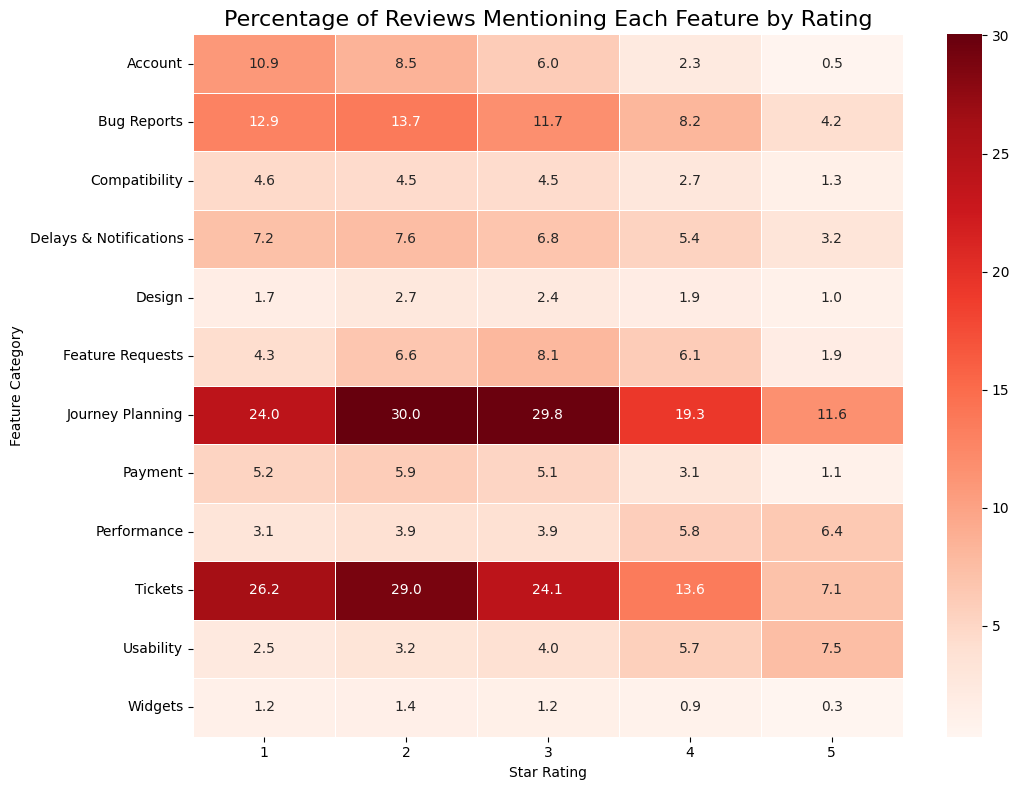

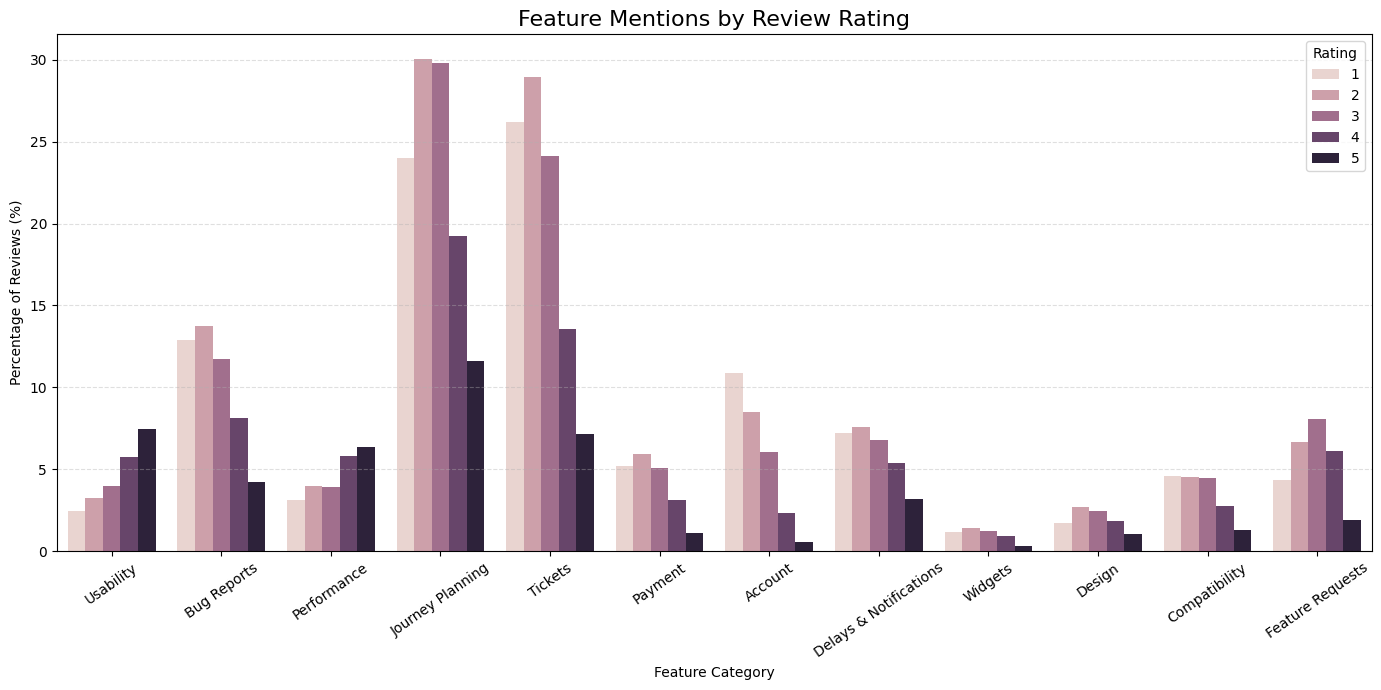


================ TOTAL FEATURE MENTIONS ================

Feature
Journey Planning          14552
Tickets                   13573
Bug Reports                6863
Account                    4465
Delays & Notifications     4037
Feature Requests           3045
Performance                2964
Usability                  2904
Payment                    2701
Compatibility              2396
Design                     1169
Widgets                     649
Name: Mentions, dtype: int64


In [60]:
# =========================================================
# FEATURE ANALYSIS BY STAR RATING
#
# Goal:
# Analyze which DB Navigator feature categories
# are discussed across different user ratings.
#
# This helps identify:
#
# - major sources of dissatisfaction
# - highly appreciated features
# - opportunities for improvement
#
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# CREATE FEATURE ANALYSIS FUNCTION
# =========================================================

def analyze_features_by_rating(df, feature_keywords):

    results = []

    for feature, keywords in feature_keywords.items():

        for rating in sorted(df["score"].unique()):

            subset = df[df["score"] == rating]

            mentions = (
                subset["clean_text"]
                .apply(
                    lambda text: any(
                        f" {keyword} " in f" {text} "
                        for keyword in keywords
                    )
                )
                .sum()
            )

            percentage = (
                mentions / len(subset) * 100
                if len(subset) > 0
                else 0
            )

            results.append({
                "Feature": feature,
                "Rating": rating,
                "Mentions": mentions,
                "Percentage": percentage
            })

    return pd.DataFrame(results)


# =========================================================
# RUN ANALYSIS
# =========================================================

feature_rating_df = analyze_features_by_rating(
    reviews,
    feature_keywords
)


# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n================ FEATURE ANALYSIS ================\n")

for rating in sorted(reviews["score"].unique()):

    print(f"\n===== {rating} Star Reviews =====\n")

    display(
        feature_rating_df[
            feature_rating_df["Rating"] == rating
        ].sort_values(
            "Mentions",
            ascending=False
        )
    )


# =========================================================
# CREATE HEATMAP
# =========================================================

pivot = feature_rating_df.pivot(
    index="Feature",
    columns="Rating",
    values="Percentage"
)

plt.figure(figsize=(11,8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=.5
)

plt.title(
    "Percentage of Reviews Mentioning Each Feature by Rating",
    fontsize=16
)

plt.xlabel("Star Rating")

plt.ylabel("Feature Category")

plt.tight_layout()

plt.show()


# =========================================================
# GROUPED BAR CHART
# =========================================================

plt.figure(figsize=(14,7))

sns.barplot(
    data=feature_rating_df,
    x="Feature",
    y="Percentage",
    hue="Rating"
)

plt.title(
    "Feature Mentions by Review Rating",
    fontsize=16
)

plt.xlabel("Feature Category")

plt.ylabel("Percentage of Reviews (%)")

plt.xticks(rotation=35)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()


# =========================================================
# MOST DISCUSSED FEATURES
# =========================================================

summary = (
    feature_rating_df
    .groupby("Feature")["Mentions"]
    .sum()
    .sort_values(ascending=False)
)

print("\n================ TOTAL FEATURE MENTIONS ================\n")

print(summary)

In [61]:
# =========================================================
# TOPIC MODELING USING LATENT DIRICHLET ALLOCATION (LDA)
#
# Goal:
# Discover the main discussion topics in
# positive and negative DB Navigator reviews.
#
# =========================================================


# =========================================================
# 1. SPLIT REVIEWS BY RATING
#
# Positive reviews:
# Ratings 4-5
#
# Neutral reviews:
# Rating 3
#
# Negative reviews:
# Ratings 1-2
#
# =========================================================

positive_reviews = reviews[reviews["score"] >= 4]

neutral_reviews = reviews[reviews["score"] == 3]

negative_reviews = reviews[reviews["score"] <= 2]


# =========================================================
# 2. DEFINE LDA FUNCTION
#
# Performs:
#
# - Vectorization
# - LDA training
# - Topic visualization
#
# =========================================================

def run_lda(dataframe, title, n_topics=7):

    print(f"\n================ {title.upper()} ================\n")

    vectorizer = CountVectorizer(
        max_df=0.85,
        min_df=10,
        max_features=3000,
        ngram_range=(1, 2),
        stop_words=list(stop_words)
    )

    X = vectorizer.fit_transform(
        dataframe["clean_text"]
    )

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )

    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(lda.components_):

        print(f"\nTopic {topic_idx + 1}")

        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-11:-1]
        ]

        print(", ".join(top_words))

    return lda, vectorizer


# =========================================================
# 3. POSITIVE REVIEW TOPICS
# =========================================================

lda_pos, vectorizer_pos = run_lda(
    positive_reviews,
    "Positive Topics"
)


# =========================================================
# 4. NEGATIVE REVIEW TOPICS
# =========================================================

lda_neg, vectorizer_neg = run_lda(
    negative_reviews,
    "Negative Topics"
)


================ POSITIVE TOPICS ================


Topic 1
bus, züge, zuverlässig, wann, fahren, einwandfrei, unterwegs, schnell, ziel, hilfe

Topic 2
zuverlässig, bedienen, klappt, leicht, aktuell, gemacht, bisher, richtig, genau, tickets

Topic 3
zufrieden, probleme, nutze, praktisch, nie, zug, ab, jahren, benutze, bisher

Topic 4
wäre, ticket, tickets, beim, buchen, bahncard, zug, schön, möglich, kaufen

Topic 5
top, vielen, tolle, bedienung, dank, hilft, schnell, einfache, reisen, tut

Topic 6
angezeigt, verbindungen, verspätungen, zeigt, nützlich, verspätung, zug, sterne, schnell, empfehlen

Topic 7
übersichtlich, hilfreich, echt, schnell, update, verbindung, informationen, buchung, bedienen, fehler

================ NEGATIVE TOPICS ================


Topic 1
update, neue, version, unübersichtlich, tickets, alte, möglich, schlechter, umständlich, funktionen

Topic 2
verbindungen, angezeigt, update, verbindung, zeigt, letzten, schade, fehler, letzten update, gefunden

Topic 3
upd

# DB Navigator Review Analysis Findings

=========================================================

## Research Topic

Analyze public Google Play Store reviews of **DB Navigator** to identify user satisfaction, recurring complaints, feature requests, and factors influencing user engagement.

Text mining techniques, including keyword analysis and Latent Dirichlet Allocation (LDA), were applied to:

* identify what users value,
* identify recurring sources of frustration,
* identify the application features that most strongly influence user satisfaction.

The objective is to derive actionable insights that support the continuous improvement of user-centered digital public transportation services.

**Dataset:**
Public Google Play Store reviews of DB Navigator.

=========================================================

# Positive Topics Interpretation (What Users Value)

## Positive Topic 1 — Reliable Travel Support

**Representative keywords:**

* bus *(bus)*
* züge *(trains)*
* zuverlässig *(reliable)*
* schnell *(fast)*
* ziel *(destination)*

Users value reliable travel information, accurate train and bus services, and dependable assistance while travelling.

---

## Positive Topic 2 — Reliable Daily Usage

**Representative keywords:**

* zuverlässig *(reliable)*
* bedienen *(easy to use)*
* klappt *(works well)*
* aktuell *(up-to-date)*
* genau *(accurate)*

Users appreciate an application that is reliable, accurate, and easy to operate during everyday use.

---

## Positive Topic 3 — Practical Everyday Companion

**Representative keywords:**

* zufrieden *(satisfied)*
* praktisch *(practical)*
* nutze *(use regularly)*
* jahren *(years)*
* benutze *(use)*

Many positive reviews describe DB Navigator as a practical application that users rely on regularly for daily travel.

---

## Positive Topic 4 — Ticket Booking

**Representative keywords:**

* ticket *(ticket)*
* tickets *(tickets)*
* buchen *(book)*
* bahncard *(BahnCard)*
* kaufen *(purchase)*

Users appreciate convenient ticket purchasing and the integration of BahnCard services within the application.

=========================================================

# Negative Topics Interpretation (What Frustrates Users)

## Negative Topic 1 — Updates and User Interface Changes

**Representative keywords:**

* update *(update)*
* version *(version)*
* unübersichtlich *(confusing)*
* schlechter *(worse)*
* funktionen *(features)*

Many users report that application updates introduce usability problems, remove familiar functionality, or make the interface more difficult to navigate.

---

## Negative Topic 2 — Incorrect Journey Information

**Representative keywords:**

* verbindungen *(connections)*
* angezeigt *(displayed)*
* fehler *(errors)*
* update *(update)*
* verbindung *(connection)*

Users frequently report incorrect or missing connection information, particularly following application updates.

---

## Negative Topic 3 — Login and Authentication Problems

**Representative keywords:**

* anmelden *(sign in)*
* login *(login)*
* einloggen *(log in)*
* passwort *(password)*
* browser *(browser)*

Authentication problems are a recurring source of frustration, including login failures, password issues, and browser-based authentication problems.

---

## Negative Topic 4 — Ticket Purchasing Problems

**Representative keywords:**

* ticket *(ticket)*
* kaufen *(purchase)*
* buchen *(book)*
* deutschlandticket *(Deutschlandticket)*
* geld *(payment)*

Users frequently experience difficulties purchasing tickets, booking journeys, and using the Deutschlandticket or payment functionality.

=========================================================

# Features Influencing User Satisfaction

The feature analysis indicates that user satisfaction is primarily influenced by:

* ticket purchasing and booking,
* journey planning and connection information,
* application reliability,
* usability,
* performance and stability,
* delay notifications.

The quantitative analysis shows that **bug reports, ticket management, and journey planning are the most frequently discussed feature categories across all review ratings**. Reviews with one and two stars are dominated by discussions of software bugs, update-related failures, ticket purchasing problems, and inaccurate travel information. In contrast, four- and five-star reviews most frequently emphasize usability, reliable performance, and convenient ticket management.

Overall, the results suggest that users value an application that provides accurate travel information, reliable operation, and a seamless ticket purchasing experience. Conversely, software updates that introduce bugs, authentication issues, incorrect journey information, or booking failures are the primary drivers of user dissatisfaction. These findings provide practical guidance for prioritizing future improvements to DB Navigator and similar digital public transportation services.
